# antiSMASH Comparative Genomics EDA

- Exploring antiSMASH 8.0.4 BGC predictions across 11 microbial isolates.
 - Per-isolate antiSMASH JSON files and KnownClusterBlast hits.
    - How many BGCs each isolate has.
    - Which product types are common.
    - Which clusters match known MIBiG entries.
    - Which clusters might be novel.
 - some shared BGCs, some isolate-specific ones, and a mix of known and unknown matches
 - note: use of Claude Sonnet 5.0 and Google AI Studio for debugging & commenting

In [ ]:
import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

DATA_DIR = Path("data/MCE-antiSMASH")   # run this notebook from the repo root
isolate_dirs = sorted([p for p in DATA_DIR.iterdir() if p.is_dir() and p.name.startswith("GCF_")])
print(f"Found {len(isolate_dirs)} isolate directories")
isolate_dirs

## 1. Load & parse all isolate JSON results

 - load the antiSMASH JSON for each isolate.
 - find the single `.json` file in each isolate folder and parse it.
 - ignore Windows sidecar files like `*.Zone.Identifier`.
 - Python `json` and `pathlib`.
 - one parsed JSON object per isolate to work with in the notebook.

In [2]:
def find_result_json(isolate_dir: Path) -> Path:
    candidates = [
        p for p in isolate_dir.glob("*.json")
        if "Zone.Identifier" not in p.name
    ]
    if len(candidates) != 1:
        raise ValueError(f"Expected exactly one result JSON in {isolate_dir}, found {candidates}")
    return candidates[0]

isolate_json = {d.name: find_result_json(d) for d in isolate_dirs}
isolate_json

{'GCF_000000001.1': PosixPath('/home/rosaliewang/projects/databases/antismash/GCF_000000001.1/1A01.json'),
 'GCF_000000002.1': PosixPath('/home/rosaliewang/projects/databases/antismash/GCF_000000002.1/6D03_short.json'),
 'GCF_000000003.1': PosixPath('/home/rosaliewang/projects/databases/antismash/GCF_000000003.1/B2R04.json'),
 'GCF_000000004.1': PosixPath('/home/rosaliewang/projects/databases/antismash/GCF_000000004.1/B2R08.json'),
 'GCF_000000005.1': PosixPath('/home/rosaliewang/projects/databases/antismash/GCF_000000005.1/B2R09_short.json'),
 'GCF_000000006.1': PosixPath('/home/rosaliewang/projects/databases/antismash/GCF_000000006.1/C2M19.json'),
 'GCF_000000007.1': PosixPath('/home/rosaliewang/projects/databases/antismash/GCF_000000007.1/C2R07_2.json'),
 'GCF_000000008.1': PosixPath('/home/rosaliewang/projects/databases/antismash/GCF_000000008.1/C3M06_short.json'),
 'GCF_000000009.1': PosixPath('/home/rosaliewang/projects/databases/antismash/GCF_000000009.1/D3M06.json'),
 'GCF_0000

In [3]:
results = {}
for isolate, jpath in isolate_json.items():
    with open(jpath) as fh:
        results[isolate] = json.load(fh)

for isolate, d in results.items():
    print(f"{isolate:18s} sample={jpath.stem if False else isolate_json[isolate].stem:14s} "
          f"antismash={d.get('version'):8s} taxon={d.get('taxon'):10s} records={len(d['records'])}")

GCF_000000001.1    sample=1A01           antismash=8.0.4    taxon=bacteria   records=35
GCF_000000002.1    sample=6D03_short     antismash=8.0.4    taxon=bacteria   records=72
GCF_000000003.1    sample=B2R04          antismash=8.0.4    taxon=bacteria   records=30
GCF_000000004.1    sample=B2R08          antismash=8.0.4    taxon=bacteria   records=83
GCF_000000005.1    sample=B2R09_short    antismash=8.0.4    taxon=bacteria   records=12
GCF_000000006.1    sample=C2M19          antismash=8.0.4    taxon=bacteria   records=55
GCF_000000007.1    sample=C2R07_2        antismash=8.0.4    taxon=bacteria   records=55
GCF_000000008.1    sample=C3M06_short    antismash=8.0.4    taxon=bacteria   records=106
GCF_000000009.1    sample=D3M06          antismash=8.0.4    taxon=bacteria   records=69
GCF_000000010.1    sample=D3M17          antismash=8.0.4    taxon=bacteria   records=35
GCF_000000011.1    sample=G1M02          antismash=8.0.4    taxon=bacteria   records=105


## 2. Genome-level summary table

 - summarize each genome in one row.
 - number of contigs, total length, GC%, CDS count, and predicted BGC count.
 - to compare assembly size and quality across isolates and relate them to BGC counts.

In [4]:
genome_rows = []
for isolate, d in results.items():
    sample_name = isolate_json[isolate].stem
    n_contigs = len(d["records"])
    total_len = 0
    total_cds = 0
    total_bgc = 0
    gc_weighted = 0.0
    for r in d["records"]:
        seq_len = len(r["seq"]["data"]) if isinstance(r["seq"], dict) else len(r["seq"])
        total_len += seq_len
        gc = r.get("gc_content")
        if gc is not None:
            gc_weighted += gc * seq_len
        total_cds += sum(1 for f in r["features"] if f["type"] == "CDS")
        total_bgc += len(r.get("areas", []))
    genome_rows.append({
        "isolate": isolate,
        "sample": sample_name,
        "n_contigs": n_contigs,
        "genome_length_bp": total_len,
        "gc_content_pct": 100 * gc_weighted / total_len if total_len else np.nan,
        "n_cds": total_cds,
        "n_bgc": total_bgc,
        "bgc_per_mbp": total_bgc / (total_len / 1e6) if total_len else np.nan,
    })

genome_df = pd.DataFrame(genome_rows).sort_values("isolate").reset_index(drop=True)
genome_df

,isolate,sample,n_contigs,genome_length_bp,gc_content_pct,n_cds,n_bgc,bgc_per_mbp
0,GCF_000000001.1,1A01,35,5765342,44.026547,5118,8,1.387602
1,GCF_000000002.1,6D03_short,72,6314044,43.807329,5513,20,3.167542
2,GCF_000000003.1,B2R04,30,4230755,59.866430,4069,10,2.363644
3,GCF_000000004.1,B2R08,83,4736204,41.502984,4017,7,1.477977
4,GCF_000000005.1,B2R09_short,12,3739335,63.946317,3559,8,2.139418
5,GCF_000000006.1,C2M19,55,4160208,36.093652,3552,6,1.442236
6,GCF_000000007.1,C2R07_2,55,3431807,65.733883,3310,9,2.622525
7,GCF_000000008.1,C3M06_short,106,5011604,64.172169,4881,10,1.995369
8,GCF_000000009.1,D3M06,69,4846235,38.133293,4608,7,1.444420
9,GCF_000000010.1,D3M17,35,5756642,39.621936,4825,5,0.868562


In [5]:
genome_df.describe()

,n_contigs,genome_length_bp,gc_content_pct,n_cds,n_bgc,bgc_per_mbp
count,11.000000,1.100000e+01,11.000000,11.000000,11.000000,11.000000
mean,59.727273,4.792517e+06,49.151148,4347.272727,9.272727,1.949882
std,30.656454,8.902601e+05,11.659448,710.684190,4.076540,0.686526
min,12.000000,3.431807e+06,36.093652,3310.000000,5.000000,0.868562
25%,35.000000,4.195482e+06,40.562460,3788.000000,7.000000,1.443328
50%,55.000000,4.736204e+06,43.807329,4368.000000,8.000000,1.995369
75%,77.500000,5.384123e+06,61.906374,4853.000000,10.000000,2.451526
max,106.000000,6.314044e+06,65.733883,5513.000000,20.000000,3.167542


## 3. BGC-level table

 - make one row per predicted BGC region.
 - location, size, predicted products, detection tools, candidate kind, and contig-edge flag.
 - this lets me analyze BGC properties and filter interesting candidates.

In [6]:
def region_contig_edge(record, area):
    """True if any protocluster in this area is flagged contig_edge by antiSMASH."""
    for f in record["features"]:
        if f["type"] != "protocluster":
            continue
        loc = f.get("location", "")
        if str(area["start"]) in loc and str(area["end"]) in loc:
            return f["qualifiers"].get("contig_edge", ["False"])[0] == "True"
    return False

bgc_rows = []
for isolate, d in results.items():
    sample_name = isolate_json[isolate].stem
    for r in d["records"]:
        contig_id = r["id"]
        for i, area in enumerate(r.get("areas", []), start=1):
            protoclusters = area.get("protoclusters", {})
            categories = sorted({pc["category"] for pc in protoclusters.values()})
            tools = sorted({pc["tool"] for pc in protoclusters.values()})
            kinds = sorted({c["kind"] for c in area.get("candidates", [])})
            bgc_rows.append({
                "isolate": isolate,
                "sample": sample_name,
                "contig_id": contig_id,
                "region_num": i,
                "region_id": f"{contig_id}.region{i:03d}",
                "start": area["start"],
                "end": area["end"],
                "length_bp": area["end"] - area["start"],
                "products": "|".join(area.get("products", [])),
                "n_products": len(area.get("products", [])),
                "categories": "|".join(categories),
                "detection_tools": "|".join(tools),
                "candidate_kind": "|".join(kinds),
                "n_protoclusters": len(protoclusters),
                "contig_edge": region_contig_edge(r, area),
            })

bgc_df = pd.DataFrame(bgc_rows)
print(f"Total BGCs across all isolates: {len(bgc_df)}")
bgc_df.head(15)

Total BGCs across all isolates: 102


,isolate,sample,contig_id,region_num,region_id,start,end,length_bp,products,n_products,categories,detection_tools,candidate_kind,n_protoclusters,contig_edge
0,GCF_000000001.1,1A01,1A01_1,1,1A01_1.region001,118730,129759,11029,RiPP-like,1,RiPP,rule-based-clusters,single,1,False
1,GCF_000000001.1,1A01,1A01_2,1,1A01_2.region001,359663,413916,54253,NRP-metallophore|NRPS,2,NRPS,rule-based-clusters,chemical_hybrid,2,True
2,GCF_000000001.1,1A01,1A01_5,1,1A01_5.region001,305026,325911,20885,terpene-precursor,1,terpene,rule-based-clusters,single,1,False
3,GCF_000000001.1,1A01,1A01_13,1,1A01_13.region001,13544,57143,43599,arylpolyene,1,PKS,rule-based-clusters,single,1,False
4,GCF_000000001.1,1A01,1A01_13,2,1A01_13.region002,125812,181593,55781,PUFA|hglE-KS,2,PKS,rule-based-clusters,neighbouring|single,2,False
5,GCF_000000001.1,1A01,1A01_28,1,1A01_28.region001,0,4424,4424,RiPP-like,1,RiPP,rule-based-clusters,single,1,True
6,GCF_000000001.1,1A01,1A01_31,1,1A01_31.region001,180822,213298,32476,betalactone,1,other,rule-based-clusters,single,1,False
7,GCF_000000001.1,1A01,1A01_35,1,1A01_35.region001,78685,100736,22051,opine-like-metallophore,1,other,rule-based-clusters,single,1,False
8,GCF_000000002.1,6D03_short,6D03_3,1,6D03_3.region001,22559,33408,10849,RiPP-like,1,RiPP,rule-based-clusters,single,1,True
9,GCF_000000002.1,6D03_short,6D03_9,1,6D03_9.region001,66191,132792,66601,NRPS,1,NRPS,rule-based-clusters,single,1,False


### Explode multi-product regions

 - some regions list multiple products with `|`.
 - split those labels and count each product separately.
 - product-frequency tables treat each product once per region.

In [7]:
bgc_products_long = (
    bgc_df.assign(product=bgc_df["products"].str.split("|"))
    .explode("product")
    .reset_index(drop=True)
)
bgc_products_long[["isolate", "region_id", "product"]].head(10)

,isolate,region_id,product
0,GCF_000000001.1,1A01_1.region001,RiPP-like
1,GCF_000000001.1,1A01_2.region001,NRP-metallophore
2,GCF_000000001.1,1A01_2.region001,NRPS
3,GCF_000000001.1,1A01_5.region001,terpene-precursor
4,GCF_000000001.1,1A01_13.region001,arylpolyene
5,GCF_000000001.1,1A01_13.region002,PUFA
6,GCF_000000001.1,1A01_13.region002,hglE-KS
7,GCF_000000001.1,1A01_28.region001,RiPP-like
8,GCF_000000001.1,1A01_31.region001,betalactone
9,GCF_000000001.1,1A01_35.region001,opine-like-metallophore


## 4. KnownClusterBlast nearest-known-cluster annotation

 - find the top KnownClusterBlast hit for each region.
 - parse `knownclusterblast/<contig>_c<N>.txt` files for significant hits.
 - to see which regions match characterized MIBiG clusters.
 - some regions will match known clusters; others will have no hit.

In [8]:
def parse_knownclusterblast_hits(txt_path: Path):
    """Parse every significant hit for a region, with % gene coverage.

    % gene coverage = (# query genes with a BLAST hit to that MIBiG cluster)
    / (total # genes in the query cluster). Returns a list of dicts, one per
    candidate hit, each also carrying the Cumulative BLAST score (antiSMASH's
    own ranking criterion, used here only to break gene-coverage ties).
    """
    text = txt_path.read_text(errors="replace")

    qm = re.search(
        r"Table of genes, locations, strands and annotations of query cluster:\s*\n(.*?)\n\s*\n",
        text, re.S,
    )
    n_query_genes = len([l for l in qm.group(1).splitlines() if l.strip()]) if qm else 0

    hits_m = re.search(r"Significant hits:\s*\n(.*?)\n\s*\n", text, re.S)
    if not hits_m or n_query_genes == 0:
        return []
    hit_lines = re.findall(r"^\d+\.\s+(\S+)\s+(.+)$", hits_m.group(1), re.M)

    # per-hit detail blocks carry gene-hit count and cumulative BLAST score
    info_by_bgc = {}
    for block in re.split(r"\n>>\n", text)[1:]:
        bm = re.match(r"\s*\d+\.\s+(\S+)", block)
        pm = re.search(r"Number of proteins with BLAST hits to this cluster:\s*(\d+)", block)
        sm = re.search(r"Cumulative BLAST score:\s*([\d.]+)", block)
        if bm and pm:
            info_by_bgc[bm.group(1)] = (int(pm.group(1)), float(sm.group(1)) if sm else None)

    hits = []
    for bgc_id, product in hit_lines:
        n_hit_genes, cum_score = info_by_bgc.get(bgc_id, (None, None))
        pct_cov = 100 * n_hit_genes / n_query_genes if n_hit_genes is not None else None
        hits.append({
            "bgc_id": bgc_id,
            "product": product.strip(),
            "pct_gene_coverage": pct_cov,
            "cumulative_blast_score": cum_score,
        })
    return hits


def parse_best_knownclusterblast_hit(txt_path: Path):
    """Single best hit per BGC: highest % gene coverage, ties broken by
    Cumulative BLAST score (both figures kept for transparency)."""
    hits = parse_knownclusterblast_hits(txt_path)
    if not hits:
        return None, None, None, None
    best = max(
        hits,
        key=lambda h: (
            h["pct_gene_coverage"] if h["pct_gene_coverage"] is not None else -1,
            h["cumulative_blast_score"] if h["cumulative_blast_score"] is not None else -1,
        ),
    )
    return best["bgc_id"], best["product"], best["pct_gene_coverage"], len(hits)

kcb_rows = []
for isolate, jpath in isolate_json.items():
    kcb_dir = jpath.parent / "knownclusterblast"
    if not kcb_dir.is_dir():
        continue
    for txt in sorted(kcb_dir.glob("*_c*.txt")):
        if "Zone.Identifier" in txt.name:
            continue
        m = re.match(r"(.+)_c(\d+)\.txt$", txt.name)
        if not m:
            continue
        contig_id, region_num = m.group(1), int(m.group(2))
        bgc_id, product, pct_cov, n_candidates = parse_best_knownclusterblast_hit(txt)
        kcb_rows.append({
            "isolate": isolate,
            "contig_id": contig_id,
            "region_num": region_num,
            "region_id": f"{contig_id}.region{region_num:03d}",
            "top_known_bgc": bgc_id,
            "top_known_product": product,
            "top_known_pct_gene_coverage": pct_cov,
            "n_mibig_candidates": n_candidates,
        })

kcb_df = pd.DataFrame(kcb_rows)
bgc_df = bgc_df.merge(
    kcb_df[["isolate", "region_id", "top_known_bgc", "top_known_product",
            "top_known_pct_gene_coverage", "n_mibig_candidates"]],
    on=["isolate", "region_id"], how="left",
)
n_with_hit = bgc_df["top_known_bgc"].notna().sum()
n_multi_candidate = (bgc_df["n_mibig_candidates"] > 1).sum()
print(f"{n_with_hit}/{len(bgc_df)} regions have a significant KnownClusterBlast hit")
print(f"{n_multi_candidate} of those had >1 candidate MIBiG match; each is now reduced to its single "
      f"best % gene coverage match (ties broken by Cumulative BLAST score)")
bgc_df[["isolate", "region_id", "products", "top_known_bgc", "top_known_product", "top_known_pct_gene_coverage"]].head(15)

45/102 regions have a significant KnownClusterBlast hit
28 of those had >1 candidate MIBiG match; each is now reduced to its single best % gene coverage match (ties broken by Cumulative BLAST score)


,isolate,region_id,products,top_known_bgc,top_known_product,top_known_pct_gene_coverage
0,GCF_000000001.1,1A01_1.region001,RiPP-like,NaN,NaN,NaN
1,GCF_000000001.1,1A01_2.region001,NRP-metallophore|NRPS,BGC0002691.2,amphibactin B/amphibactin C/amphibactin D/amph...,20.512821
2,GCF_000000001.1,1A01_5.region001,terpene-precursor,NaN,NaN,NaN
3,GCF_000000001.1,1A01_13.region001,arylpolyene,BGC0000837.4,APE Vf,38.636364
4,GCF_000000001.1,1A01_13.region002,PUFA|hglE-KS,BGC0000865.3,eicoseicosapentaenoic acid,14.285714
5,GCF_000000001.1,1A01_28.region001,RiPP-like,NaN,NaN,NaN
6,GCF_000000001.1,1A01_31.region001,betalactone,NaN,NaN,NaN
7,GCF_000000001.1,1A01_35.region001,opine-like-metallophore,BGC0002490.2,yersinopine,8.333333
8,GCF_000000002.1,6D03_3.region001,RiPP-like,NaN,NaN,NaN
9,GCF_000000002.1,6D03_9.region001,NRPS,NaN,NaN,NaN


## 5. BGC counts and MIBiG match summary per isolate

 - summarize counts and MIBiG match rates per isolate.
 - total BGCs, number with MIBiG hit, number without, and percent matched.
 - to compare how well each isolate's BGCs map to known chemistry.

In [9]:
mibig_summary = (
    bgc_df.assign(has_mibig_hit=bgc_df["top_known_bgc"].notna())
    .groupby("isolate")
    .agg(
        sample=("sample", "first"),
        n_bgc=("region_id", "size"),
        n_mibig_hit=("has_mibig_hit", "sum"),
    )
)
mibig_summary["n_no_hit"] = mibig_summary["n_bgc"] - mibig_summary["n_mibig_hit"]
mibig_summary["pct_mibig_hit"] = (100 * mibig_summary["n_mibig_hit"] / mibig_summary["n_bgc"]).round(1)
mibig_summary = mibig_summary.sort_values("n_bgc", ascending=False)[
    ["sample", "n_bgc", "n_mibig_hit", "n_no_hit", "pct_mibig_hit"]
]
mibig_summary


,sample,n_bgc,n_mibig_hit,n_no_hit,pct_mibig_hit
isolate,,,,,
GCF_000000002.1,6D03_short,20,11,9,55.0
GCF_000000011.1,G1M02,12,6,6,50.0
GCF_000000003.1,B2R04,10,4,6,40.0
GCF_000000008.1,C3M06_short,10,3,7,30.0
GCF_000000007.1,C2R07_2,9,3,6,33.3
GCF_000000001.1,1A01,8,4,4,50.0
GCF_000000005.1,B2R09_short,8,2,6,25.0
GCF_000000009.1,D3M06,7,5,2,71.4
GCF_000000004.1,B2R08,7,2,5,28.6


## 6. BGC counts per isolate

 - visualize how BGC counts vary across isolates.
 - some isolates will be richer in BGCs than others.

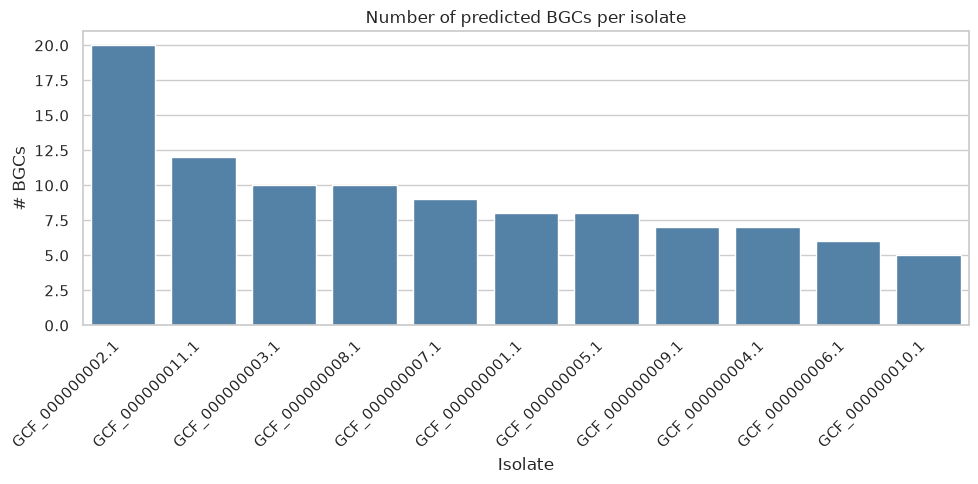

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
order = genome_df.sort_values("n_bgc", ascending=False)["isolate"]
sns.barplot(data=genome_df, x="isolate", y="n_bgc", order=order, ax=ax, color="steelblue")
ax.set_title("Number of predicted BGCs per isolate")
ax.set_xlabel("Isolate")
ax.set_ylabel("# BGCs")
for tick in ax.get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")
plt.tight_layout()
plt.show()

## 7. BGC product-type distribution

 - check which product types are common overall.
 - count product labels and plot frequencies.
 - to spot dominant biosynthetic classes and hybrids.

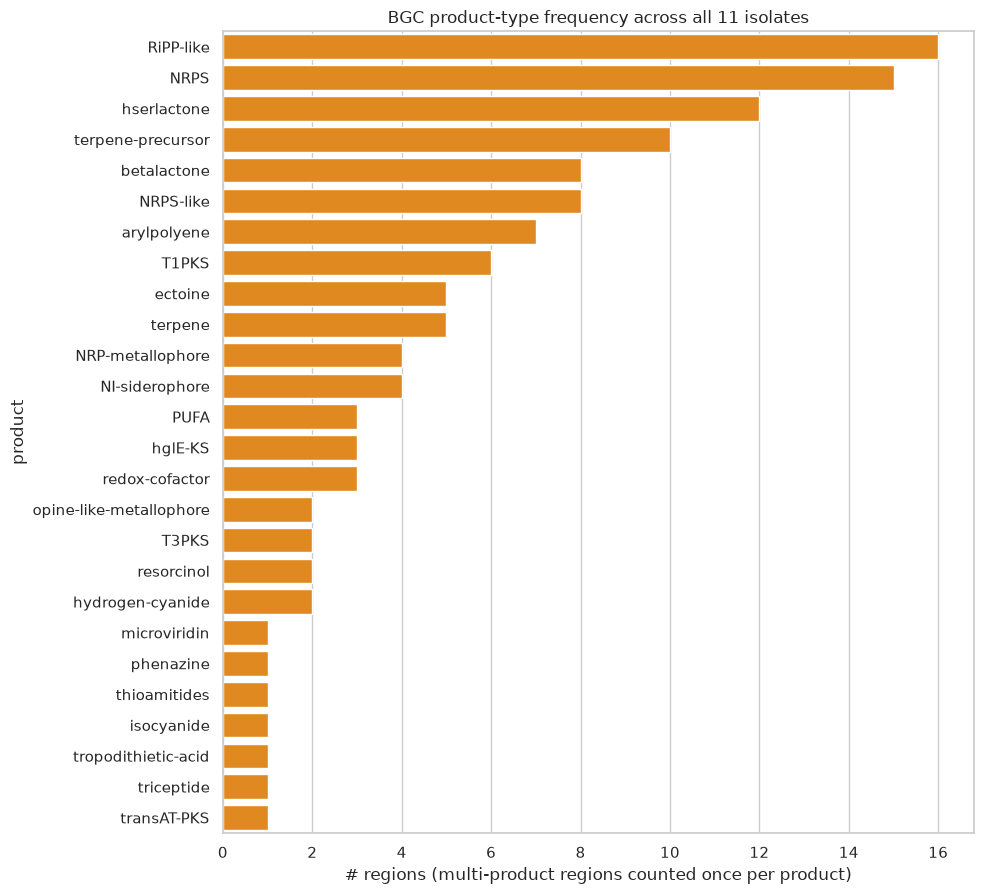

In [11]:
product_counts = bgc_products_long["product"].value_counts()
fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(product_counts))))
sns.barplot(x=product_counts.values, y=product_counts.index, ax=ax, color="darkorange")
ax.set_title("BGC product-type frequency across all 11 isolates")
ax.set_xlabel("# regions (multi-product regions counted once per product)")
plt.tight_layout()
plt.show()

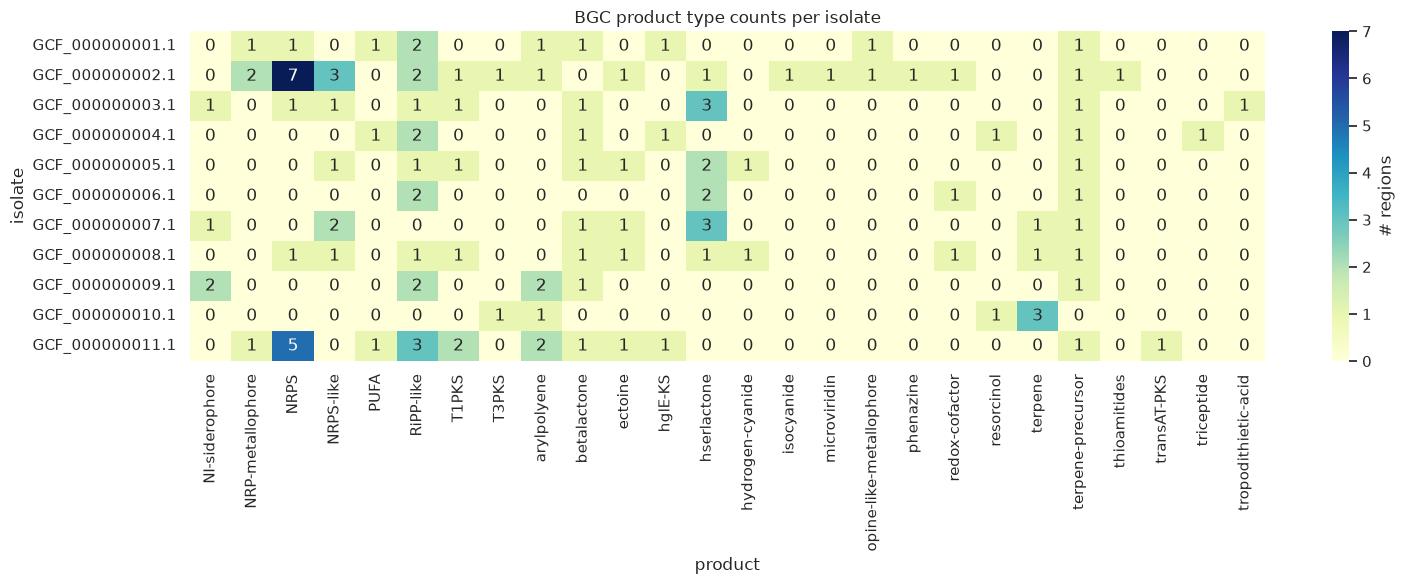

product,NI-siderophore,NRP-metallophore,NRPS,NRPS-like,PUFA,RiPP-like,T1PKS,T3PKS,arylpolyene,betalactone,ectoine,hglE-KS,hserlactone,hydrogen-cyanide,isocyanide,microviridin,opine-like-metallophore,phenazine,redox-cofactor,resorcinol,terpene,terpene-precursor,thioamitides,transAT-PKS,triceptide,tropodithietic-acid
isolate,,,,,,,,,,,,,,,,,,,,,,,,,,
GCF_000000001.1,0,1,1,0,1,2,0,0,1,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0
GCF_000000002.1,0,2,7,3,0,2,1,1,1,0,1,0,1,0,1,1,1,1,1,0,0,1,1,0,0,0
GCF_000000003.1,1,0,1,1,0,1,1,0,0,1,0,0,3,0,0,0,0,0,0,0,0,1,0,0,0,1
GCF_000000004.1,0,0,0,0,1,2,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0
GCF_000000005.1,0,0,0,1,0,1,1,0,0,1,1,0,2,1,0,0,0,0,0,0,0,1,0,0,0,0
GCF_000000006.1,0,0,0,0,0,2,0,0,0,0,0,0,2,0,0,0,0,0,1,0,0,1,0,0,0,0
GCF_000000007.1,1,0,0,2,0,0,0,0,0,1,1,0,3,0,0,0,0,0,0,0,1,1,0,0,0,0
GCF_000000008.1,0,0,1,1,0,1,1,0,0,1,1,0,1,1,0,0,0,0,1,0,1,1,0,0,0,0
GCF_000000009.1,2,0,0,0,0,2,0,0,2,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [12]:
# Isolate x product-type count matrix
pivot = (
    bgc_products_long.groupby(["isolate", "product"]).size()
    .unstack(fill_value=0)
    .reindex(sorted(genome_df["isolate"]))
)
fig, ax = plt.subplots(figsize=(max(8, 0.6 * pivot.shape[1]), 6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={"label": "# regions"}, ax=ax)
ax.set_title("BGC product type counts per isolate")
plt.tight_layout()
plt.show()
pivot

## 8. BGC main-category frequency (antiSMASH-native, one category per BGC)

 - use antiSMASH's own protocluster `category` field (NRPS, PKS, RiPP, terpene, other) rather than exploding the free-text `products` labels.
 - collapse each BGC to exactly one category so counts total 102 (# BGCs), not 124.
 - 11 BGCs carry >1 antiSMASH category tag (genuine hybrids, e.g. `NRPS|PKS`); for these, any named category beats the catch-all `other`, and among named categories NRPS > PKS > RiPP > terpene (the classic modular biosynthetic machinery takes precedence over ribosomal/terpene pathways when combined).</cell id="efb03a79">


In [13]:
# antiSMASH's own protocluster-category field, collapsed to one label per BGC.
CATEGORY_LABELS = {"NRPS": "NRP", "PKS": "Polyketide", "RiPP": "RiPP", "terpene": "Terpenoid", "other": "Other"}
CATEGORY_PRIORITY = ["NRPS", "PKS", "RiPP", "terpene", "other"]

def pick_main_category(categories_str: str) -> str:
    cats = categories_str.split("|") if categories_str else ["other"]
    for pref in CATEGORY_PRIORITY:
        if pref in cats:
            return CATEGORY_LABELS[pref]
    return "Other"

bgc_df["main_category"] = bgc_df["categories"].apply(pick_main_category)

n_hybrid = bgc_df["categories"].str.contains(r"\|").sum()
print(f"{n_hybrid}/{len(bgc_df)} BGCs carry >1 antiSMASH category tag; each collapsed to one via "
      f"priority NRPS > PKS > RiPP > terpene > other")

category_counts = bgc_df["main_category"].value_counts()
print(f"Total: {category_counts.sum()} (== {len(bgc_df)} BGCs, one category each)")
category_counts


11/102 BGCs carry >1 antiSMASH category tag; each collapsed to one via priority NRPS > PKS > RiPP > terpene > other
Total: 102 (== 102 BGCs, one category each)


main_category
Other         33
NRP           22
RiPP          21
Terpenoid     15
Polyketide    11
Name: count, dtype: int64

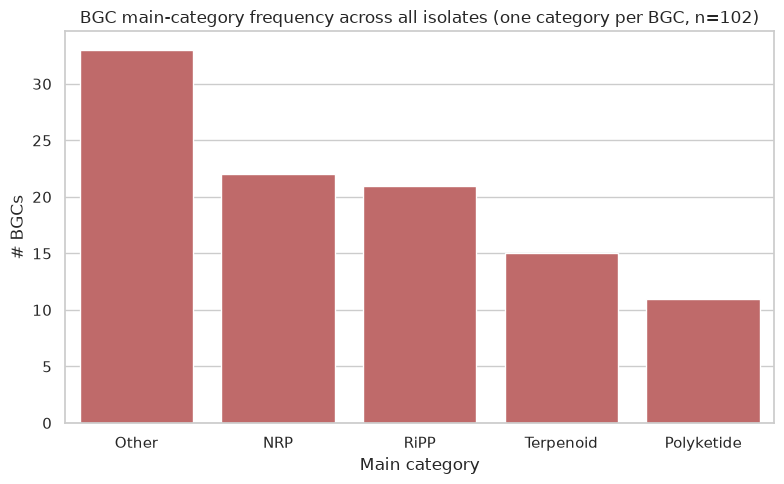

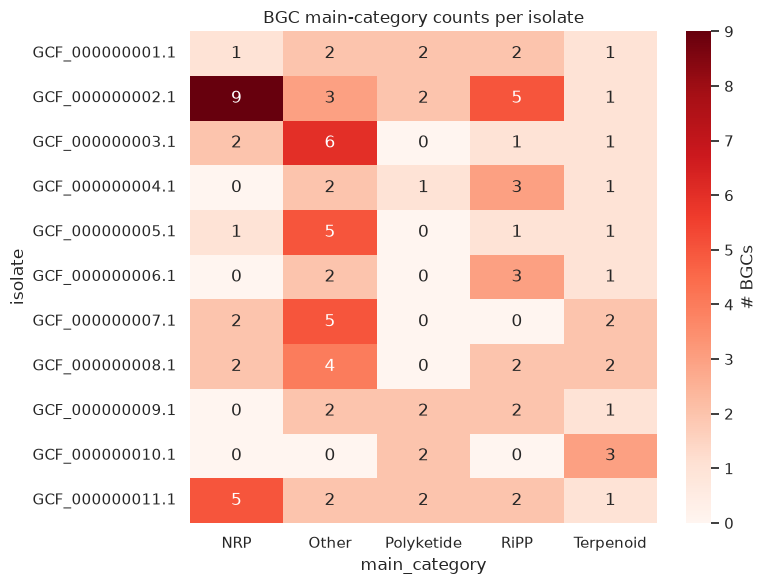

main_category,NRP,Other,Polyketide,RiPP,Terpenoid
isolate,,,,,
GCF_000000001.1,1,2,2,2,1
GCF_000000002.1,9,3,2,5,1
GCF_000000003.1,2,6,0,1,1
GCF_000000004.1,0,2,1,3,1
GCF_000000005.1,1,5,0,1,1
GCF_000000006.1,0,2,0,3,1
GCF_000000007.1,2,5,0,0,2
GCF_000000008.1,2,4,0,2,2
GCF_000000009.1,0,2,2,2,1


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax,
            order=category_counts.index, color="indianred")
ax.set_title("BGC main-category frequency across all isolates (one category per BGC, n=102)")
ax.set_ylabel("# BGCs")
ax.set_xlabel("Main category")
plt.tight_layout()
plt.show()

# Isolate x main-category count matrix (one category per BGC)
category_pivot = (
    bgc_df.groupby(["isolate", "main_category"]).size()
    .unstack(fill_value=0)
    .reindex(sorted(genome_df["isolate"]))
)
fig, ax = plt.subplots(figsize=(max(8, 0.8 * category_pivot.shape[1]), 6))
sns.heatmap(category_pivot, annot=True, fmt="d", cmap="Reds", cbar_kws={"label": "# BGCs"}, ax=ax)
ax.set_title("BGC main-category counts per isolate")
plt.tight_layout()
plt.show()
category_pivot


### 8b. MIBiG match rate by main category

 - of the 102 BGCs (one main_category each), how many of the 45 MIBiG-matched BGCs fall in each category?
 - compare against each category's total BGC count to see which categories are well- vs. poorly-characterized.

Total BGCs: 102 | MIBiG-matched: 45 | Unmatched: 57


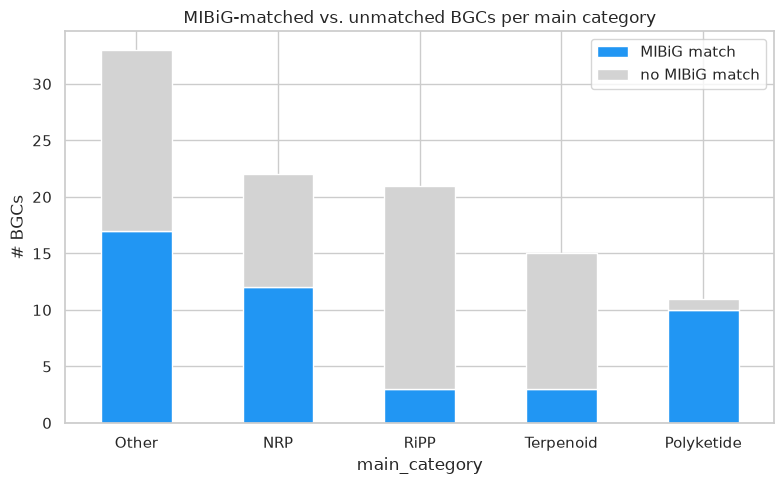

,total_bgc,n_mibig_hit,n_no_hit,pct_mibig_hit
main_category,,,,
Other,33,17,16,51.5
NRP,22,12,10,54.5
RiPP,21,3,18,14.3
Terpenoid,15,3,12,20.0
Polyketide,11,10,1,90.9


In [15]:
category_mibig_summary = (
    bgc_df.assign(has_mibig_hit=bgc_df["top_known_bgc"].notna())
    .groupby("main_category")
    .agg(total_bgc=("region_id", "size"), n_mibig_hit=("has_mibig_hit", "sum"))
    .reindex(category_counts.index)  # keep same category order as the bar chart above
)
category_mibig_summary["n_no_hit"] = category_mibig_summary["total_bgc"] - category_mibig_summary["n_mibig_hit"]
category_mibig_summary["pct_mibig_hit"] = (
    100 * category_mibig_summary["n_mibig_hit"] / category_mibig_summary["total_bgc"]
).round(1)

print(f"Total BGCs: {category_mibig_summary['total_bgc'].sum()} | "
      f"MIBiG-matched: {category_mibig_summary['n_mibig_hit'].sum()} | "
      f"Unmatched: {category_mibig_summary['n_no_hit'].sum()}")
category_mibig_summary

fig, ax = plt.subplots(figsize=(8, 5))
category_mibig_summary[["n_mibig_hit", "n_no_hit"]].plot(
    kind="bar", stacked=True, ax=ax, color=["#2196F3", "lightgray"]
)
ax.set_title("MIBiG-matched vs. unmatched BGCs per main category")
ax.set_ylabel("# BGCs")
ax.legend(["MIBiG match", "no MIBiG match"])
for tick in ax.get_xticklabels():
    tick.set_rotation(0)
plt.tight_layout()
plt.show()

category_mibig_summary

## 9. BGC size distribution

 - examine the length distribution of predicted regions.
 - plot histograms and per-isolate boxplots of region length (kb).
 - very short or very long regions may indicate false positives or multi-modular clusters.

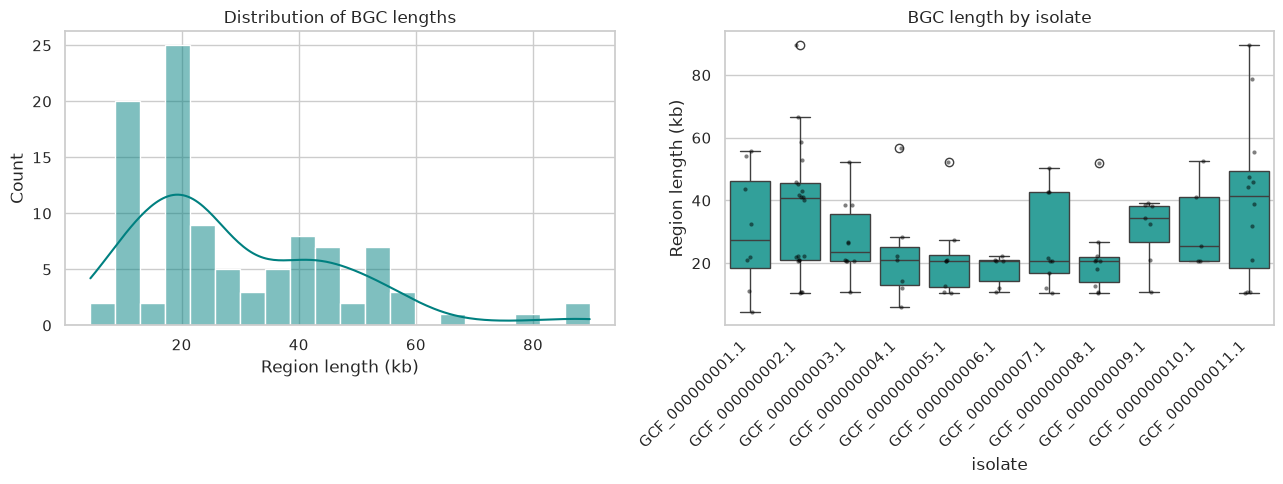

count      102.000000
mean     29470.607843
std      17714.897991
min       4424.000000
25%      20567.750000
50%      22077.000000
75%      41191.000000
max      89672.000000
Name: length_bp, dtype: float64

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(bgc_df["length_bp"] / 1000, bins=20, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribution of BGC lengths")
axes[0].set_xlabel("Region length (kb)")

order2 = genome_df.sort_values("isolate")["isolate"]
sns.boxplot(data=bgc_df, x="isolate", y=bgc_df["length_bp"] / 1000, order=order2, ax=axes[1], color="lightseagreen")
sns.stripplot(data=bgc_df, x="isolate", y=bgc_df["length_bp"] / 1000, order=order2, ax=axes[1], color="black", alpha=0.5, size=3)
axes[1].set_title("BGC length by isolate")
axes[1].set_ylabel("Region length (kb)")
for tick in axes[1].get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")

plt.tight_layout()
plt.show()

bgc_df["length_bp"].describe()

## 10. Contig-edge (potentially fragmented) clusters

 - identify clusters that touch contig edges.
 - edge clusters may be fragmented by assembly breaks.
 - flag regions with `contig_edge=True` and summarize per isolate.

In [17]:
edge_summary = (
    bgc_df.groupby("isolate")["contig_edge"]
    .agg(n_total="size", n_edge="sum")
    .assign(pct_edge=lambda x: 100 * x["n_edge"] / x["n_total"])
    .sort_values("pct_edge", ascending=False)
)
edge_summary

,n_total,n_edge,pct_edge
isolate,,,
GCF_000000004.1,7,4,57.142857
GCF_000000009.1,7,4,57.142857
GCF_000000007.1,9,4,44.444444
GCF_000000011.1,12,5,41.666667
GCF_000000008.1,10,4,40.000000
GCF_000000003.1,10,3,30.000000
GCF_000000001.1,8,2,25.000000
GCF_000000002.1,20,5,25.000000
GCF_000000005.1,8,0,0.000000


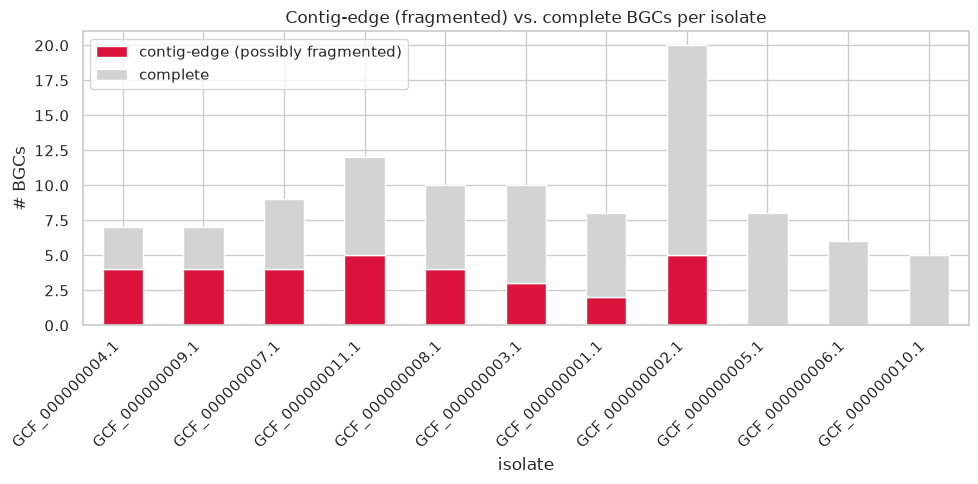

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
edge_summary[["n_edge", "n_total"]].assign(n_complete=lambda x: x["n_total"] - x["n_edge"])[["n_edge", "n_complete"]].plot(
    kind="bar", stacked=True, ax=ax, color=["crimson", "lightgray"]
)
ax.set_title("Contig-edge (fragmented) vs. complete BGCs per isolate")
ax.set_ylabel("# BGCs")
ax.legend(["contig-edge (possibly fragmented)", "complete"])
for tick in ax.get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")
plt.tight_layout()
plt.show()

## 11. Genome size, GC content, and assembly fragmentation vs. BGC count

 - test assembly-quality confounds.
 - genome length, GC%, and contig count vs. BGC count.
 - to see if assembly quality explains differences in detected BGCs.

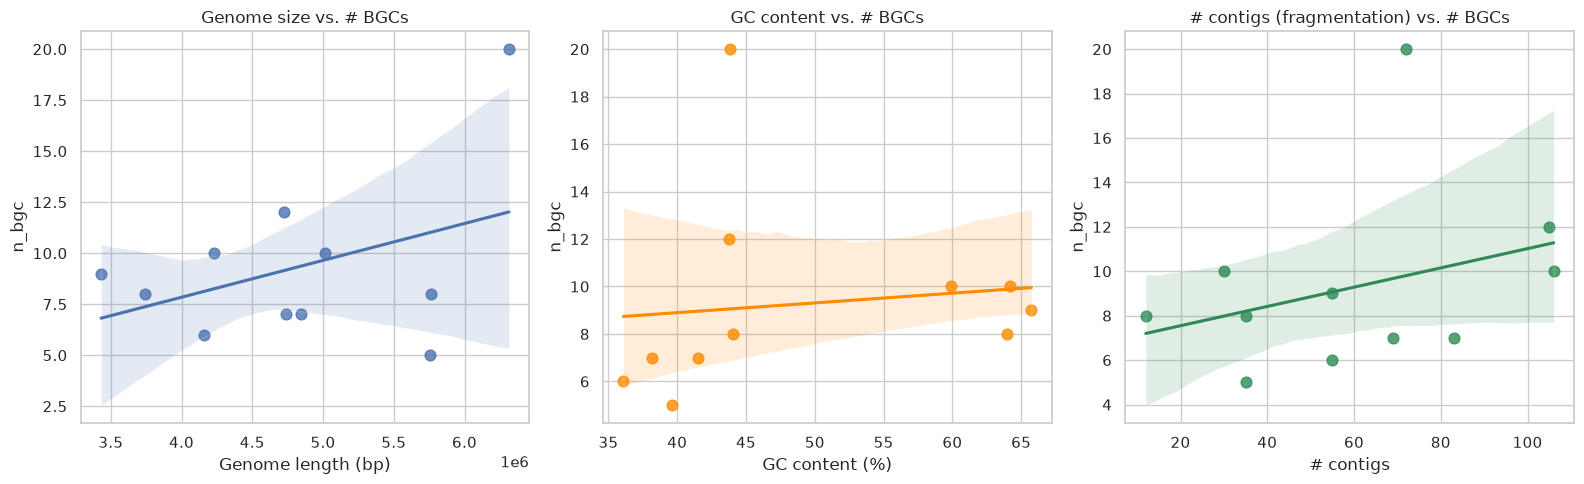

,genome_length_bp,gc_content_pct,n_contigs,n_cds,n_bgc,bgc_per_mbp
genome_length_bp,1.000000,-0.527187,0.195866,0.953543,0.394554,-0.129792
gc_content_pct,-0.527187,1.000000,-0.160538,-0.345560,0.117243,0.479498
n_contigs,0.195866,-0.160538,1.000000,0.267865,0.326327,0.221341
n_cds,0.953543,-0.345560,0.267865,1.000000,0.475373,-0.005832
n_bgc,0.394554,0.117243,0.326327,0.475373,1.000000,0.850330
bgc_per_mbp,-0.129792,0.479498,0.221341,-0.005832,0.850330,1.000000


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.regplot(data=genome_df, x="genome_length_bp", y="n_bgc", ax=axes[0], scatter_kws={"s": 60})
axes[0].set_title("Genome size vs. # BGCs")
axes[0].set_xlabel("Genome length (bp)")

sns.regplot(data=genome_df, x="gc_content_pct", y="n_bgc", ax=axes[1], scatter_kws={"s": 60}, color="darkorange")
axes[1].set_title("GC content vs. # BGCs")
axes[1].set_xlabel("GC content (%)")

sns.regplot(data=genome_df, x="n_contigs", y="n_bgc", ax=axes[2], scatter_kws={"s": 60}, color="seagreen")
axes[2].set_title("# contigs (fragmentation) vs. # BGCs")
axes[2].set_xlabel("# contigs")

plt.tight_layout()
plt.show()

genome_df[["genome_length_bp", "gc_content_pct", "n_contigs", "n_cds", "n_bgc", "bgc_per_mbp"]].corr()

## 12. BGC diversity per isolate

 - measure product-type diversity per isolate.
 - Shannon index on the isolate x product count matrix (found this on the internet)
     - higher index = more diverse BGC repertoire.
     - H = 0: Indicates a community with no diversity (only one species is present).
     - Low values: Suggest a community dominated by a few species or with low species richness.- Higher values: Indicate a highly diverse, heterogeneous community with an equal distribution of different species.

In [20]:
def shannon_index(counts):
    counts = np.array(counts, dtype=float)
    counts = counts[counts > 0]
    if counts.sum() == 0:
        return 0.0
    p = counts / counts.sum()
    return float(-(p * np.log(p)).sum())

diversity = pivot.apply(shannon_index, axis=1).rename("shannon_index").to_frame()
diversity["n_bgc"] = pivot.sum(axis=1)
diversity["n_product_types"] = (pivot > 0).sum(axis=1)
diversity = diversity.sort_values("shannon_index", ascending=False)
diversity

,shannon_index,n_bgc,n_product_types
isolate,,,
GCF_000000002.1,2.500797,26,16
GCF_000000008.1,2.397895,11,11
GCF_000000011.1,2.201512,19,11
GCF_000000001.1,2.163956,10,9
GCF_000000003.1,2.098274,11,9
GCF_000000005.1,2.043192,9,8
GCF_000000004.1,1.906155,8,7
GCF_000000007.1,1.834372,10,7
GCF_000000009.1,1.559581,8,5


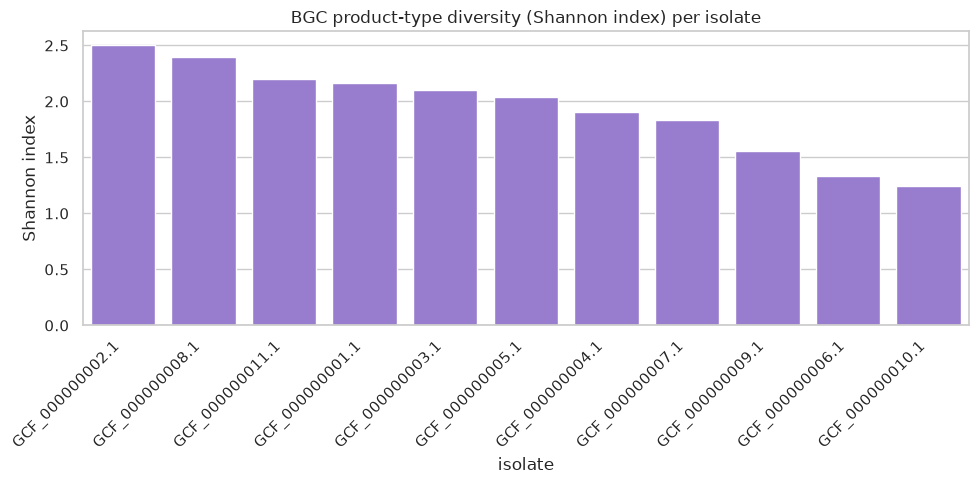

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=diversity.index, y=diversity["shannon_index"], ax=ax, color="mediumpurple")
ax.set_title("BGC product-type diversity (Shannon index) per isolate")
ax.set_ylabel("Shannon index")
for tick in ax.get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")
plt.tight_layout()
plt.show()

## 13. Closest known clusters across isolates

 - list MIBiG clusters that match regions in our isolates.
 - recurring matches suggest shared biosynthetic functions.
 - clusters found in multiple isolates vs. isolate-unique hits.

In [22]:
known_hits = bgc_df.dropna(subset=["top_known_product"])
hit_summary = (
    known_hits.groupby(["top_known_bgc", "top_known_product"])["isolate"]
    .agg(n_isolates="nunique", isolates=lambda s: sorted(set(s)))
    .sort_values("n_isolates", ascending=False)
)
hit_summary

,,n_isolates,isolates
top_known_bgc,top_known_product,,
BGC0002284.3,corynecin III/corynecin I/corynecin II,4,"[GCF_000000003.1, GCF_000000004.1, GCF_0000000..."
BGC0000837.4,APE Vf,3,"[GCF_000000001.1, GCF_000000009.1, GCF_0000000..."
BGC0000860.3,ectoine,3,"[GCF_000000005.1, GCF_000000007.1, GCF_0000000..."
BGC0000865.3,eicoseicosapentaenoic acid,2,"[GCF_000000001.1, GCF_000000011.1]"
BGC0002490.2,yersinopine,2,"[GCF_000000001.1, GCF_000000002.1]"
BGC0000460.5,vulnibactin,1,[GCF_000000002.1]
BGC0000350.5,ET-743,1,[GCF_000000006.1]
BGC0000295.5,acinetoferrin,1,[GCF_000000009.1]
BGC0000635.3,carotenoid,1,[GCF_000000007.1]


In [23]:
regions_without_known_hit = bgc_df[bgc_df["top_known_bgc"].isna()]
print(f"{len(regions_without_known_hit)}/{len(bgc_df)} regions have NO significant match to a characterized MIBiG cluster")
print("-> candidates for potentially novel biosynthetic chemistry:")
regions_without_known_hit[["isolate", "region_id", "products", "length_bp", "contig_edge"]].sort_values("length_bp", ascending=False).head(50)

57/102 regions have NO significant match to a characterized MIBiG cluster
-> candidates for potentially novel biosynthetic chemistry:


,isolate,region_id,products,length_bp,contig_edge
9,GCF_000000002.1,6D03_9.region001,NRPS,66601,False
95,GCF_000000011.1,gnlProkkaGGEFLBJO_10.region002,arylpolyene|T1PKS|NRPS,55412,False
13,GCF_000000002.1,6D03_26.region001,NRPS,52851,False
31,GCF_000000003.1,P1_E12_3.region001,T1PKS|NRPS-like,52187,False
50,GCF_000000005.1,B2R09_12.region002,T1PKS|NRPS-like,52163,False
68,GCF_000000008.1,C3M06_4.region001,T1PKS|NRPS-like,51994,False
92,GCF_000000011.1,gnlProkkaGGEFLBJO_8.region001,NRPS,45910,False
22,GCF_000000002.1,6D03_59.region001,NRPS,45766,False
97,GCF_000000011.1,gnlProkkaGGEFLBJO_13.region001,NRPS,44233,False
65,GCF_000000007.1,P2_A5_21.region001,NRPS-like,42622,False


## 14. Dataset summary

 - overall counts, most common product, most diverse isolate, and percent novel candidates.

In [24]:
top_isolate_count = genome_df.loc[genome_df["n_bgc"].idxmax()]
top_product = product_counts.index[0]
most_diverse = diversity.index[0]
pct_no_hit = 100 * len(regions_without_known_hit) / len(bgc_df)

print(f"Across {len(genome_df)} isolates: {len(bgc_df)} BGCs total "
      f"({genome_df['n_bgc'].mean():.1f} +/- {genome_df['n_bgc'].std():.1f} per isolate).")
print(f"Most BGC-rich isolate: {top_isolate_count['isolate']} ({top_isolate_count['sample']}) "
      f"with {int(top_isolate_count['n_bgc'])} BGCs.")
print(f"Most common product type: '{top_product}' ({product_counts.iloc[0]} regions).")
print(f"Most diverse BGC repertoire: {most_diverse} (Shannon index = {diversity.loc[most_diverse, 'shannon_index']:.2f}).")
print(f"{edge_summary['n_edge'].sum()} / {len(bgc_df)} BGCs ({100*edge_summary['n_edge'].sum()/len(bgc_df):.1f}%) sit on a contig edge (possibly fragmented).")
print(f"{pct_no_hit:.1f}% of regions have no significant MIBiG KnownClusterBlast hit (potential novelty).")

Across 11 isolates: 102 BGCs total (9.3 +/- 4.1 per isolate).
Most BGC-rich isolate: GCF_000000002.1 (6D03_short) with 20 BGCs.
Most common product type: 'RiPP-like' (16 regions).
Most diverse BGC repertoire: GCF_000000002.1 (Shannon index = 2.50).
31 / 102 BGCs (30.4%) sit on a contig edge (possibly fragmented).
55.9% of regions have no significant MIBiG KnownClusterBlast hit (potential novelty).
